Figure 2 in the paper: Lower bound of posterior vulnerability as the domain of the sensitive attribute $n_S$ grows.

It uses equations of Propostion 6.1 (prior vulnerability) and Theorem 6.4 (limit of posterior vulnerability).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

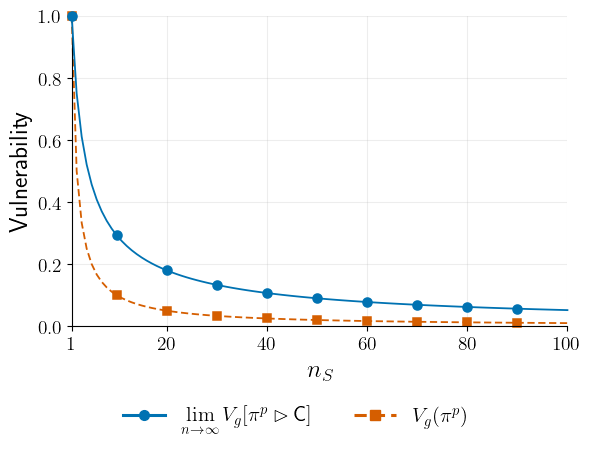

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amssymb}",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "lines.linewidth": 2.2,
    "figure.figsize": (5.8, 3.8),
})

# Parameters
ns_min = 1
ns_max = 100

# Functions
def limit_posterior_vul(ns):
    harmonic = np.sum(1 / np.arange(1, ns + 1))
    return harmonic / ns

def prior_vul(ns):
    return 1 / ns

# Data
ns_values = np.arange(ns_min, ns_max + 1)
y_limit = np.array([limit_posterior_vul(ns) for ns in ns_values])
y_prior = np.array([prior_vul(ns) for ns in ns_values])

fig, ax = plt.subplots(constrained_layout=True)

marker_idx = np.array([1] + list(range(10, 100, 10))) - 1

# Main curve
ax.plot(
    ns_values,
    y_limit,
    color="#0072B2",
    marker="o",
    markevery=marker_idx,
    markersize=6.5,
    markeredgewidth=1.1,
    linewidth=1.3,
    label=r"$\lim\limits_{n\to\infty} V_g[\pi^p \rhd {\sf C}]$",
    zorder=3,
    clip_on=False,
)

# Second curve
ax.plot(
    ns_values,
    y_prior,
    color="#D55E00",
    marker="s",
    markevery=marker_idx,
    markersize=6.0,
    markeredgewidth=1.1,
    linewidth=1.3,
    linestyle=(0, (4, 2)),
    label=r"$V_g(\pi^p)$",
    zorder=2,
    clip_on=False,
)

ax.set_xlabel(r"$n_S$")
ax.set_ylabel("Vulnerability")
ax.set_xlim(ns_min, ns_max)
ax.set_ylim(0, 1)

ax.set_xticks([1, 20, 40, 60, 80, 100])
ax.set_yticks(np.linspace(0, 1, 6))

ax.grid(True, which="major", axis="both", alpha=0.22, linewidth=0.8)
ax.set_axisbelow(True)

legend_handles = [
    Line2D(
        [0], [0],
        color="#0072B2",
        marker="o",
        linewidth=2.2,
        markersize=7,
        label=r"$\lim\limits_{n\to\infty} V_g[\pi^p \rhd {\sf C}]$"
    ),
    Line2D(
        [0], [0],
        color="#D55E00",
        marker="s",
        linestyle=(0, (4, 2)),
        linewidth=2.2,
        markersize=7,
        label=r"$V_g(\pi^p)$"
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.18),
)

plt.show()